# <span style="font-family:serif; font-size:28px;"> Content</span>

1. Project Overview
    * Project Motivation and Objective
    * Type 2 Diabetes
    * Health and Economic Relevance
    * Dataset Background
2. Dataset Understanding
3. Environment Setup and Data Loading
4. Missing Values Analysis
5. Data Visualization
    * Target Variable Distribution
    * Feature Type Classification
    * Univariate Analysis
        * Key Observations from Binary Features
        * Key Observations from Numeric Features
        * Key Observations from Ordinal Features
    * Correlation Analysis
    * Interpreting the Correlation Results
    * Feature Selection
6. Data Preprocessing
    * Define Features and Target
    * Split the Dataset
    * Create Preprocessing Pipeline
7. Machine Learning Model Selection
    * Model Comparison
    * Model Optimization and Selection
8. Model Evaluation
    * Initial Prediction Performance Analysis
    * ROC Curve Analysis
    * Precision-Recall Curve Analysis
    * Threshold Adjustment
    * Feature Importance
9. Conclusions

# <span style="font-family:serif; font-size:28px;"> 1. Project Overview</span>

### 1.1 Project Motivation and Objective
Type 2 diabetes is one of the most common chronic diseases and continues to represent a major public health challenge. Because it is influenced by a combination of behavioral, clinical, and socioeconomic factors, it is a strong candidate for data-driven analysis and predictive modeling.

The objective of this project is to examine patterns in individuals with and without diabetes in order to identify the factors most strongly associated with the disease. Based on these patterns, the goal is to build a predictive model that can estimate whether an individual may be at risk of developing diabetes using health, lifestyle, and demographic information.

### 1.2 Type 2 Diabetes
Type 2 diabetes is a chronic condition that affects the body’s ability to regulate blood glucose properly. It develops when the body becomes resistant to insulin or does not produce enough of it to maintain normal glucose levels. Over time, this can lead to persistent hyperglycemia and increase the risk of serious health complications.

Several factors are commonly associated with the development of Type 2 diabetes, including obesity, physical inactivity, poor diet, smoking, high blood pressure, high cholesterol, age, and genetic predisposition. Socioeconomic conditions such as income, education, and access to healthcare may also influence risk and disease management.

### 1.3 Health and Economic Relevance
Diabetes can have a significant impact on quality of life and is associated with complications such as cardiovascular disease, kidney disease, vision loss, nerve damage, and lower-limb amputations. These outcomes often require long-term treatment and continuous medical attention.

In addition to its clinical consequences, diabetes also places a substantial economic burden on individuals, families, and healthcare systems. Early identification of risk factors may help support prevention efforts and reduce both health-related and financial costs.

### 1.4 Dataset Background
This project uses data from the Behavioral Risk Factor Surveillance System (BRFSS), an annual health survey conducted by the Centers for Disease Control and Prevention (CDC). The survey collects information on chronic conditions, preventive healthcare, and lifestyle behaviors from a large sample of individuals across the United States.

For this analysis, a cleaned and balanced subset of the 2015 BRFSS dataset was used. It contains 70,692 survey responses and 21 feature variables. The target variable, `Diabetes_binary`, divides respondents into two groups: no diabetes (`0`) and prediabetes or diabetes (`1`).

# <span style="font-family:serif; font-size:28px;">2. Dataset Understanding</span>

This dataset contains health, lifestyle, and demographic variables used to support diabetes prediction.

The target variable is **`Diabetes_binary`**:
- `0` = No diabetes
- `1` = Diabetes

Some variables are binary, while others are ordinal or numerical. In particular, `Age`, `Education`, `Income`, and `GenHlth` are encoded categories rather than continuous measures.


| Feature | Type | Description |
|---|---|---|
| **HighBP** | Binary | History of high blood pressure diagnosis. |
| **HighChol** | Binary | History of high cholesterol diagnosis. |
| **CholCheck** | Binary | Received a cholesterol check within the past 5 years. |
| **BMI** | Numerical | Body Mass Index. |
| **Smoker** | Binary | Has smoked at least 100 cigarettes in lifetime. |
| **Stroke** | Binary | Ever had a stroke. |
| **HeartDiseaseorAttack** | Binary | Ever had coronary heart disease or a heart attack. |
| **PhysActivity** | Binary | Performed physical activity or exercise during the past 30 days. |
| **Fruits** | Binary | Consumes fruit at least once per day. |
| **Veggies** | Binary | Consumes vegetables at least once per day. |
| **HvyAlcoholConsump** | Binary | Heavy alcohol consumption. |
| **AnyHealthcare** | Binary | Has any type of healthcare coverage. |
| **NoDocbcCost** | Binary | Could not see a doctor in the past 12 months because of cost. |
| **GenHlth** | Ordinal | Self-rated general health on a scale from 1 to 5, where higher values indicate poorer health. |
| **MentHlth** | Numerical | Number of days during the past 30 days when mental health was not good. |
| **PhysHlth** | Numerical | Number of days during the past 30 days when physical health was not good. |
| **DiffWalk** | Binary | Has serious difficulty walking or climbing stairs. |
| **Sex** | Binary | Sex of respondent (`0 = Female`, `1 = Male`). |
| **Age** | Ordinal | Age group encoded from 1 to 14. |
| **Education** | Ordinal | Highest grade or year of school completed, encoded from 1 to 6. |
| **Income** | Ordinal | Annual household income category, encoded from 1 to 8. |

# <span style="font-family:serif; font-size:28px;">3. Environment Setup and Data Loading</span>

Before beginning the analysis, the required Python libraries are imported and the dataset is loaded into the notebook environment. These libraries will be used for data manipulation, visualization, preprocessing, and machine learning throughout the project. Once the dataset is loaded, an initial inspection will be performed to better understand its structure, variables, and overall data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    roc_curve,
    auc,
    average_precision_score,
    PrecisionRecallDisplay
)

KeyboardInterrupt: 

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file path
file_path = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "alexteboul/diabetes-health-indicators-dataset",
    file_path,
)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.


In [ ]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [ ]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


# <span style="font-family:serif; font-size:28px;">4. Missing Values Analysis</span>

Before proceeding with the exploratory analysis and model development, it is important to verify the completeness of the dataset. Although this dataset is expected to contain no missing values, a missing data analysis will be performed to ensure there are no null or incomplete observations that could affect the analysis. The `missingno` library will be used to visualize the distribution of missing values across the dataset.

<Figure size 1200x600 with 0 Axes>

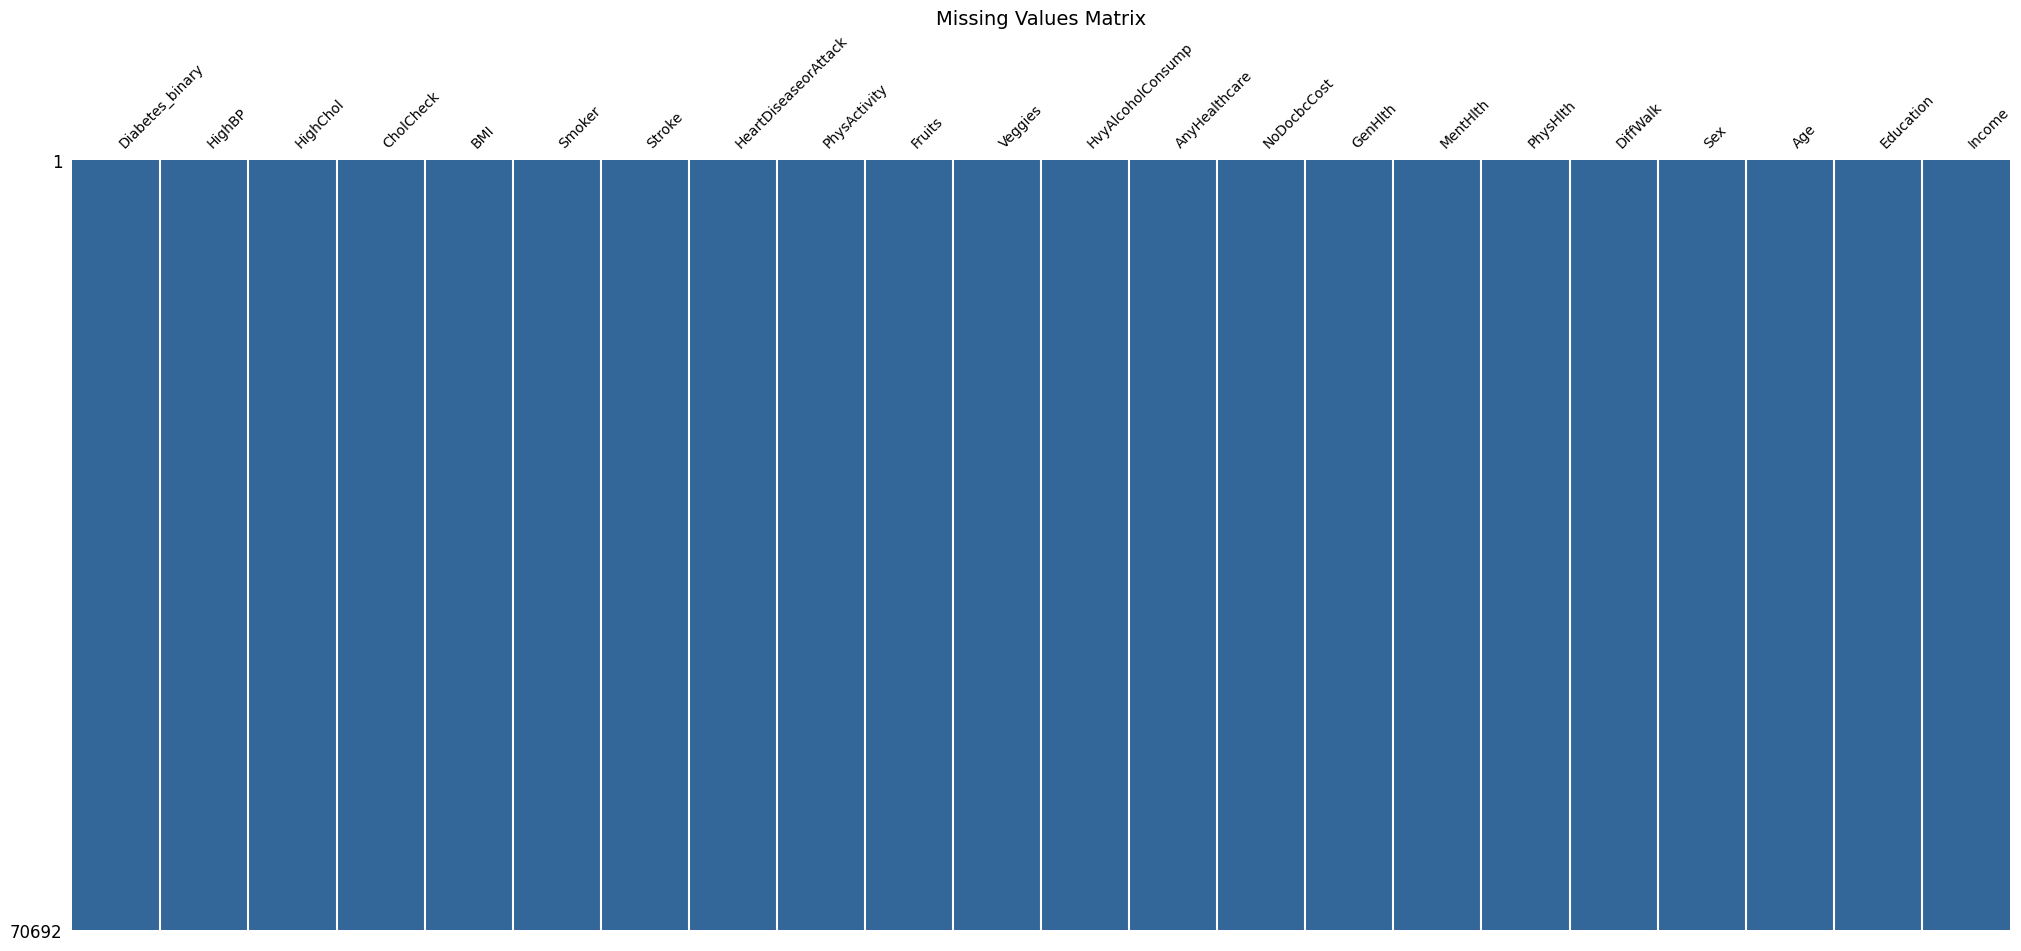

In [ ]:
plt.figure(figsize=(12,6))

msno.matrix(
    df,
    color=(0.2, 0.4, 0.6),
    fontsize=10,
    sparkline=False
)

plt.title('Missing Values Matrix', fontsize=14)
plt.show()

In [ ]:
for column in df.columns:
    print(f'• {column}: {df[column].isna().sum()} missing values')

• Diabetes_binary: 0 missing values
• HighBP: 0 missing values
• HighChol: 0 missing values
• CholCheck: 0 missing values
• BMI: 0 missing values
• Smoker: 0 missing values
• Stroke: 0 missing values
• HeartDiseaseorAttack: 0 missing values
• PhysActivity: 0 missing values
• Fruits: 0 missing values
• Veggies: 0 missing values
• HvyAlcoholConsump: 0 missing values
• AnyHealthcare: 0 missing values
• NoDocbcCost: 0 missing values
• GenHlth: 0 missing values
• MentHlth: 0 missing values
• PhysHlth: 0 missing values
• DiffWalk: 0 missing values
• Sex: 0 missing values
• Age: 0 missing values
• Education: 0 missing values
• Income: 0 missing values


As expected, the dataset contains no missing values. This confirms that the data is complete and suitable for further exploratory analysis and predictive modeling without requiring missing value imputation.

# <span style="font-family:serif; font-size:28px;">5. Data Visualization</span>

Data visualization plays an important role in exploratory data analysis by helping identify patterns, trends, distributions, and potential relationships between variables. Given the variety of health, demographic, and behavioral features included in this dataset, visual exploration can provide valuable insights into the characteristics of individuals with and without diabetes. The following visualizations will be used to better understand the distribution of variables and their potential association with diabetes risk.

### 5.1 Target Variable Distribution

The first step in the exploratory analysis is to examine the distribution of the target variable. Understanding the balance between individuals with and without diabetes is important, as class imbalance can influence both model performance and evaluation.

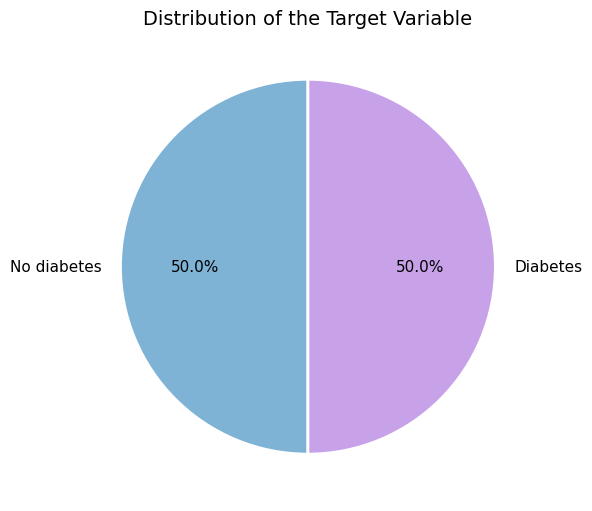

In [ ]:
# Target distribution
target_counts = df['Diabetes_binary'].value_counts().sort_index()

labels = ['No diabetes', 'Diabetes']

# Pastel color palette
colors = ['#7FB3D5', '#C8A2E8']

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    target_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)

ax.set_title('Distribution of the Target Variable', fontsize=14)

plt.tight_layout()
plt.show()

As expected, the target variable is evenly distributed, which is consistent with the dataset description. The balanced class distribution is beneficial for predictive modeling, as it reduces the risk of bias toward a majority class during training.

### 5.2 Feature Type Classification

To guide the exploratory analysis, the variables are grouped according to their data type. This classification makes it easier to choose appropriate visualizations and to interpret each feature correctly.

In [ ]:
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]

numerical_features = ['BMI', 'MentHlth', 'PhysHlth']

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']

### 5.3 Univariate Analysis

Univariate analysis focuses on examining each variable individually in order to better understand its distribution and overall behavior within the dataset. This step provides initial insights into the characteristics of the population and helps identify potential patterns, imbalances, and trends across binary, numerical, and ordinal features before exploring their relationship with diabetes.

### 5.3.1 Key Observations from Binary Features

The binary variables provide an initial view of the factors that appear to be associated with diabetes in this dataset. Several health conditions and lifestyle indicators show a noticeable relationship with the target variable. In particular, respondents with high blood pressure, high cholesterol, a history of stroke, heart disease, or difficulty walking or climbing stairs appear more likely to have diabetes. Likewise, lower levels of physical activity and being male also seem to be associated with a higher prevalence of diabetes.

Some variables show weaker or more limited separation between classes. For example, cholesterol screening and access to healthcare are relatively balanced, suggesting they may be less informative on their own. Smoking and lack of medical care due to cost show only a mild association with diabetes, while fruit and vegetable consumption appears to have a small negative relationship with the outcome. Heavy alcohol consumption also seems to have a weak inverse association.

Overall, the binary analysis suggests that conditions related to cardiovascular health, mobility, and physical activity are among the most relevant indicators, while some lifestyle and access-related variables show weaker effects.

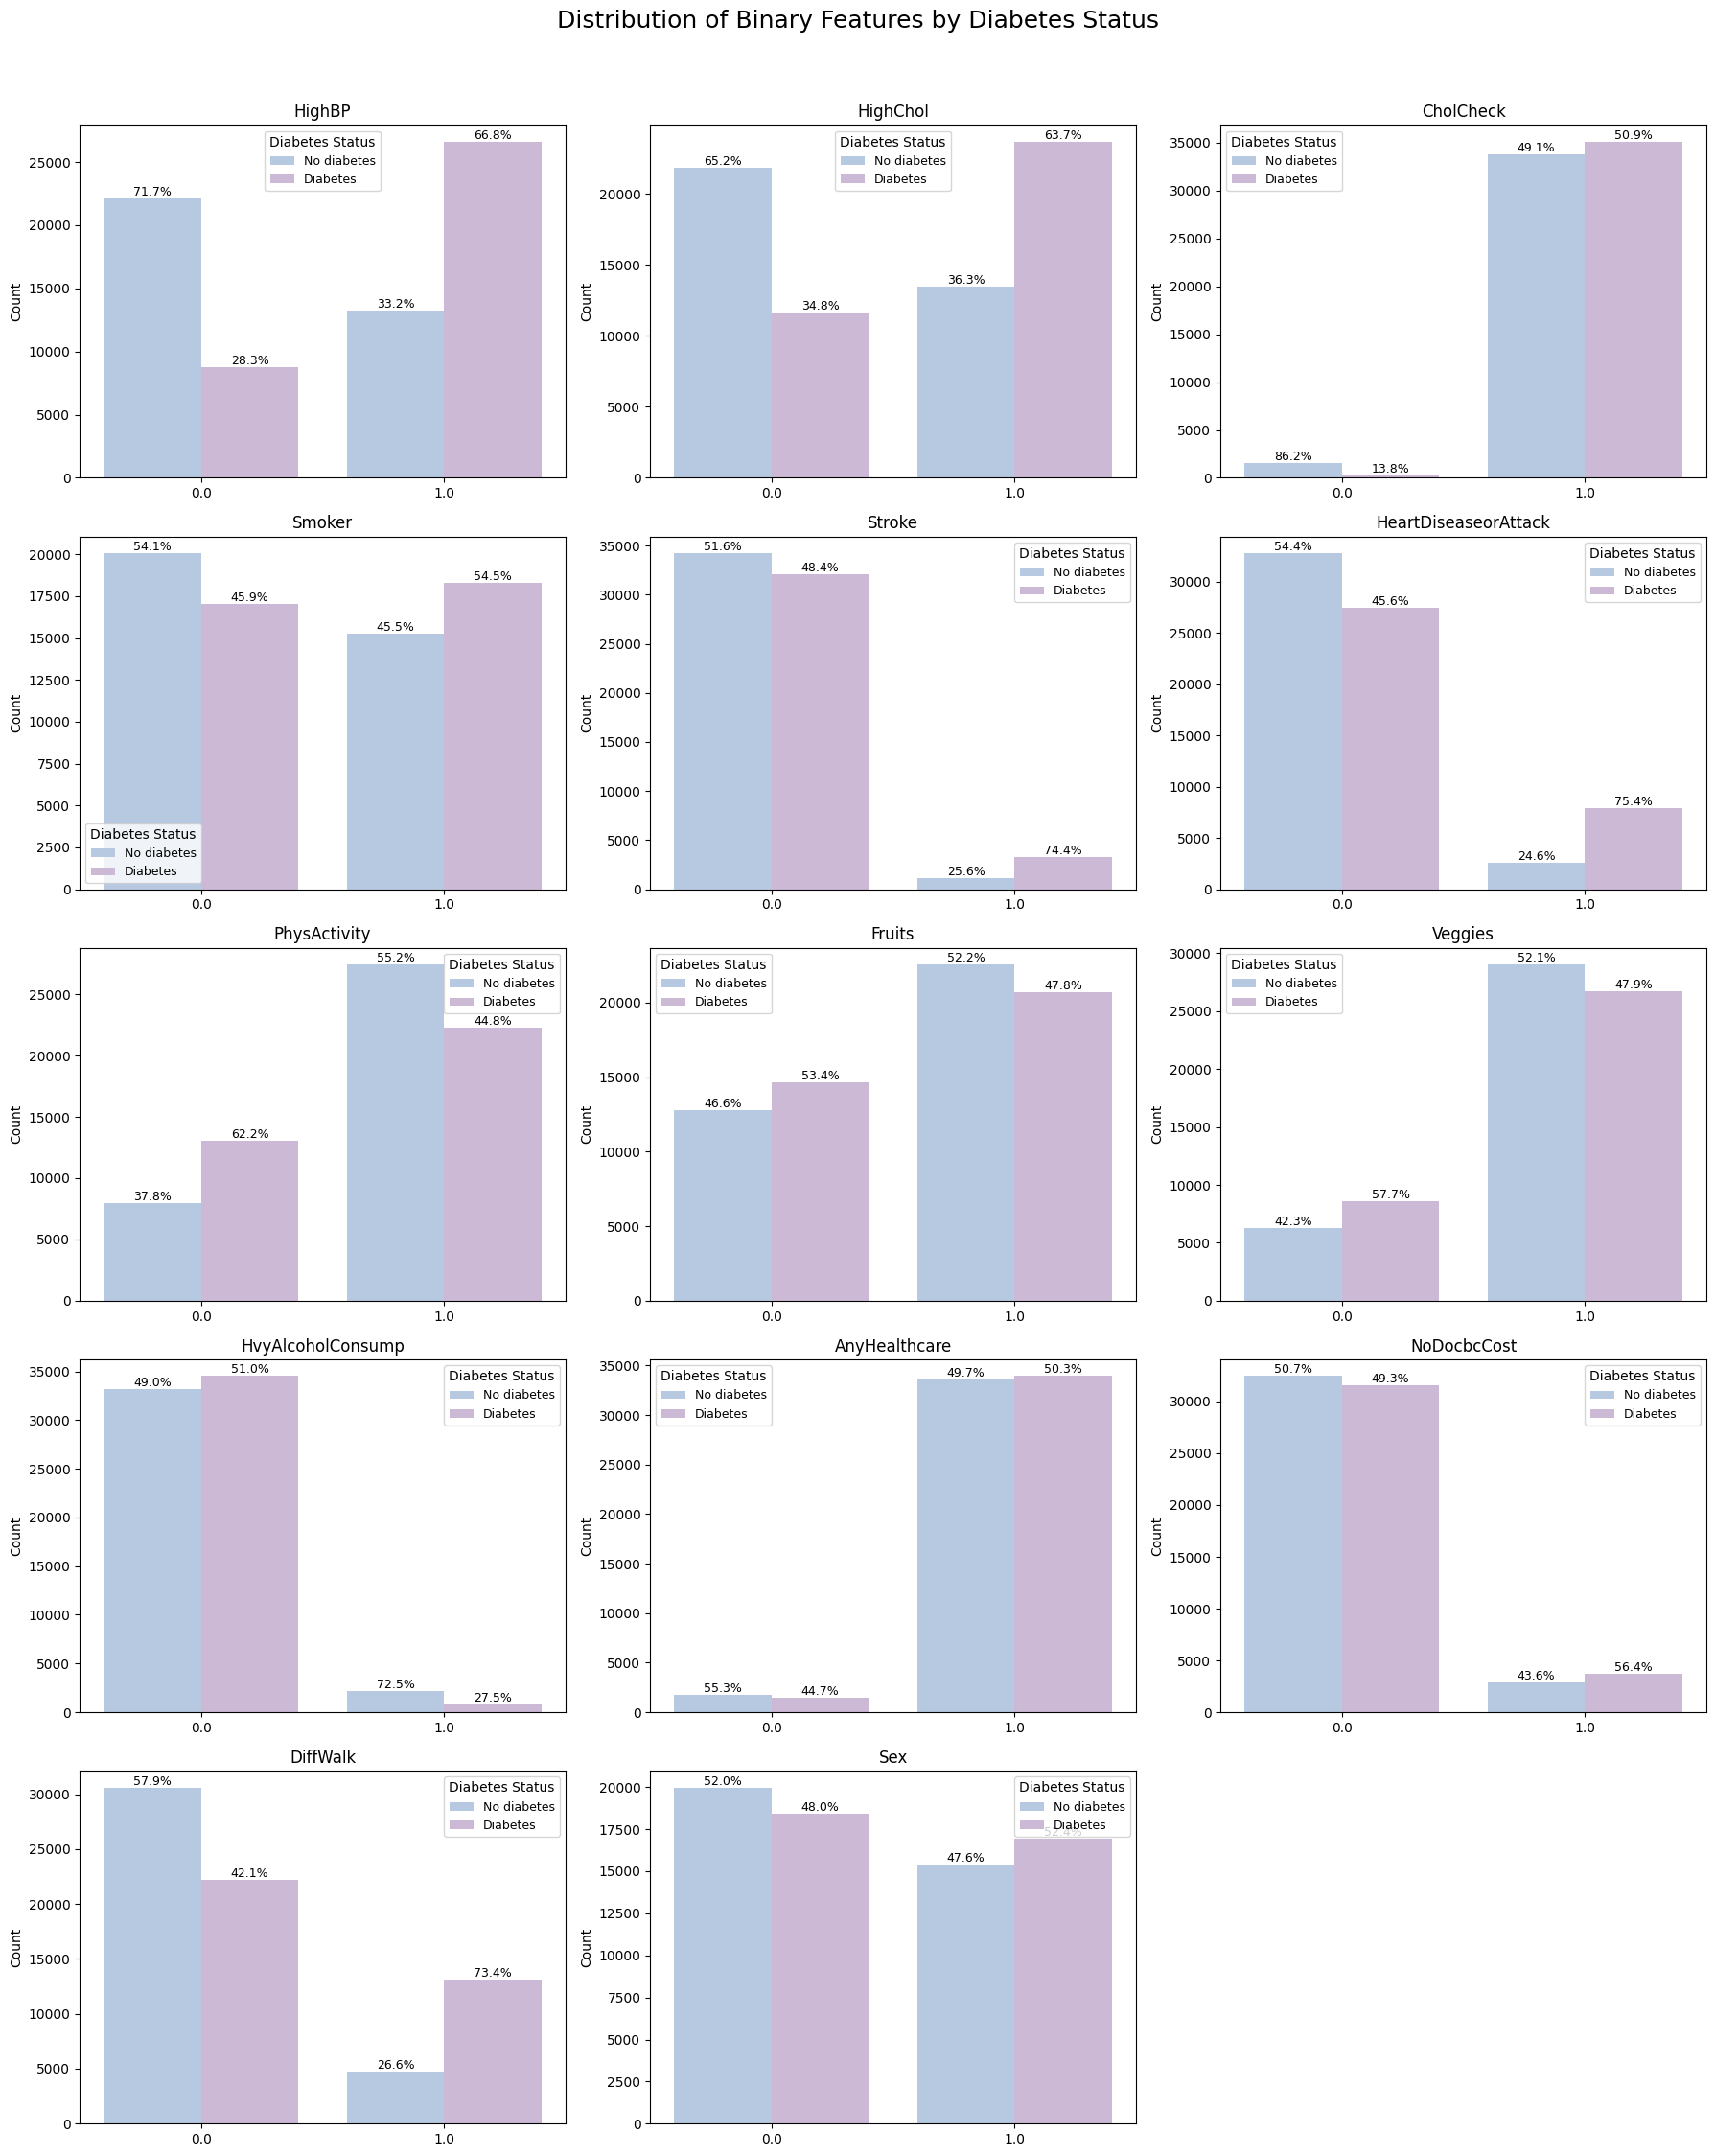

In [ ]:
# Pastel palette
palette = ['#AFC8E8', '#CDB4DB']

# Explicit ordering
hue_order = [0, 1]
hue_labels = ['No diabetes', 'Diabetes']

# Create subplot grid
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, feature in enumerate(binary_features):
    ax = axes[i]

    order = sorted(df[feature].dropna().unique())

    sns.countplot(
        data=df,
        x=feature,
        hue='Diabetes_binary',
        order=order,
        hue_order=hue_order,
        palette=palette,
        ax=ax
    )

    # Counts and within-category percentages
    counts = pd.crosstab(df[feature], df['Diabetes_binary']).reindex(index=order, columns=hue_order, fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    # Add percentage labels correctly
    for hue_idx, container in enumerate(ax.containers):
        for bar_idx, bar in enumerate(container):
            pct = percentages.iloc[bar_idx, hue_idx]
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{pct:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

    ax.set_title(feature, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, hue_labels, title='Diabetes Status', fontsize=9)

# Remove unused subplot
fig.delaxes(axes[-1])

fig.suptitle('Distribution of Binary Features by Diabetes Status', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

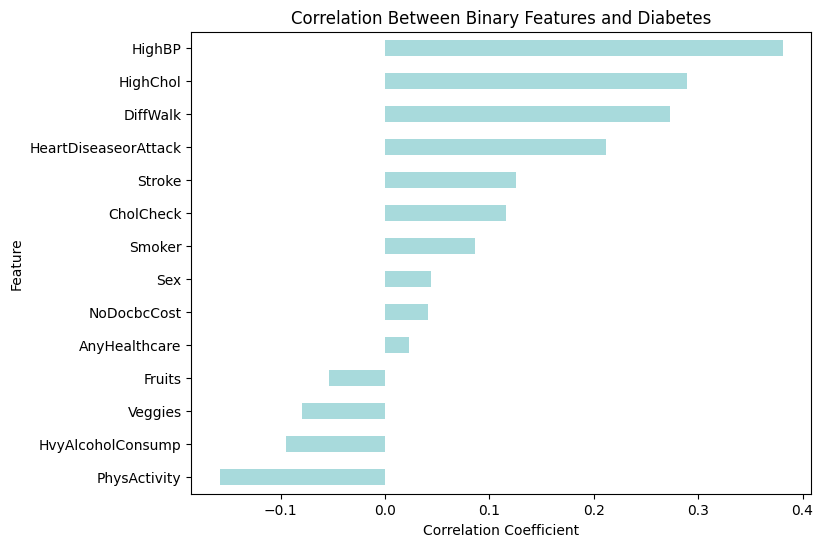

In [ ]:
plt.figure(figsize=(8, 6))

binary_correlations = (
    df[binary_features]
    .corrwith(df['Diabetes_binary'])
)

binary_correlations.sort_values().plot(
    kind='barh',
    color='#A8DADC'
)

plt.title('Correlation Between Binary Features and Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')

plt.show()

### 5.3.2 Key Observations from Numerical Features

The numerical variables provide additional insight into how health status differs between the two groups. **BMI** shows the clearest separation: individuals with diabetes appear more frequently at higher BMI values, suggesting that body weight may be an important predictor in this dataset.

For **MentalHlth**, the distribution is more similar across both groups, with no strong visual separation between individuals with and without diabetes. This suggests that mental health days may have a weaker relationship with the target variable when considered on their own.

**PhysHlth** shows a slightly stronger pattern, as individuals with diabetes tend to report more days of poor physical health. Although the difference is not as pronounced as with BMI, it may still reflect a meaningful association with diabetes risk.

Overall, among the numerical features, BMI appears to be the most informative variable, while physical health shows a moderate relationship and mental health appears less strongly associated with the target.

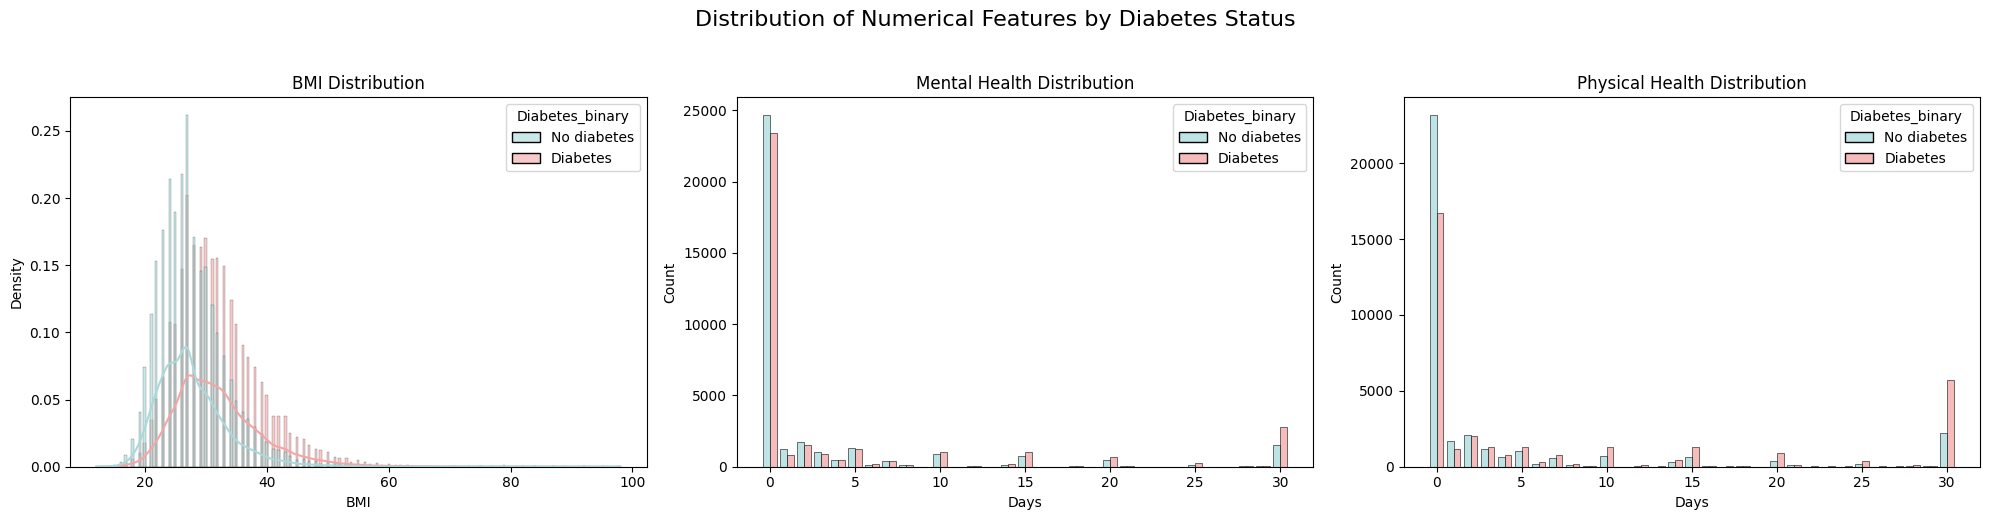

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastel palette
palette = ['#A8DADC', '#F4A6A6']

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# BMI Histogram + KDE

sns.histplot(
    data=df,
    x='BMI',
    hue='Diabetes_binary',
    kde=True,
    stat='density',
    common_norm=False,
    palette=palette,
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title('BMI Distribution', fontsize=12)
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Density')

legend = axes[0].get_legend()

if legend:
    legend.texts[0].set_text('No diabetes')
    legend.texts[1].set_text('Diabetes')

# MentHlth Distribution

sns.histplot(
    data=df,
    x='MentHlth',
    hue='Diabetes_binary',
    multiple='dodge',
    discrete=True,
    shrink=0.8,
    palette=palette,
    ax=axes[1]
)

axes[1].set_title('Mental Health Distribution', fontsize=12)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')

legend = axes[1].get_legend()

if legend:
    legend.texts[0].set_text('No diabetes')
    legend.texts[1].set_text('Diabetes')

# PhysHlth Distribution

sns.histplot(
    data=df,
    x='PhysHlth',
    hue='Diabetes_binary',
    multiple='dodge',
    discrete=True,
    shrink=0.8,
    palette=palette,
    ax=axes[2]
)

axes[2].set_title('Physical Health Distribution', fontsize=12)
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Count')

legend = axes[2].get_legend()

if legend:
    legend.texts[0].set_text('No diabetes')
    legend.texts[1].set_text('Diabetes')

# Main title
fig.suptitle(
    'Distribution of Numerical Features by Diabetes Status',
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

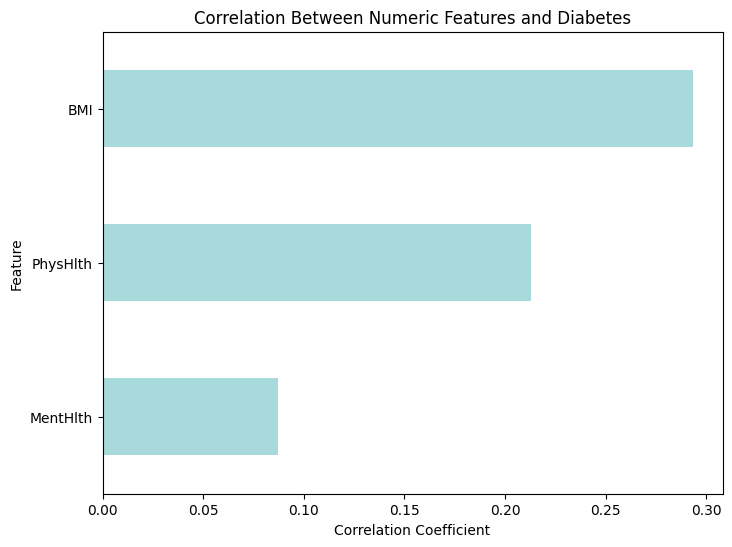

In [ ]:
plt.figure(figsize=(8, 6))

numeric_correlations = (
    df[numerical_features]
    .corrwith(df['Diabetes_binary'])
)

numeric_correlations.sort_values().plot(
    kind='barh',
    color='#A8DADC'
)

plt.title('Correlation Between Numeric Features and Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')

plt.show()

### 5.3.3 Key Observations from Ordinal Features

The ordinal variables show clear differences between individuals with and without diabetes. **General health** is one of the strongest indicators in this group: respondents who report poorer overall health are much more likely to belong to the diabetes group. This is consistent with the fact that diabetes is often associated with a broader decline in health status.

**Age** also shows a strong relationship with diabetes. As age increases, the number of individuals with diabetes rises as well, suggesting that older age groups are more affected by the condition. This pattern is expected, since diabetes risk generally increases over time due to accumulated health and lifestyle factors.

For **Education**, diabetes appears to be more common among individuals with lower educational levels. One possible explanation is that education may be related to health awareness, access to information, and preventive care, all of which can influence diabetes risk and management. However, this relationship should be interpreted cautiously, as education may also be acting as a proxy for other socioeconomic factors.

**Income** shows a similar but less consistent pattern. Diabetes seems to be more frequent in lower and middle income groups, while the highest income categories tend to have a lower proportion of diabetic individuals. This may reflect differences in access to healthcare, nutrition, lifestyle, and disease prevention resources. Overall, income appears to be associated with diabetes, but not as strongly as age or general health.

Taken together, the ordinal features suggest that **general health** and **age** are among the most informative variables, while **education** and **income** may also contribute to diabetes risk through broader socioeconomic influences.

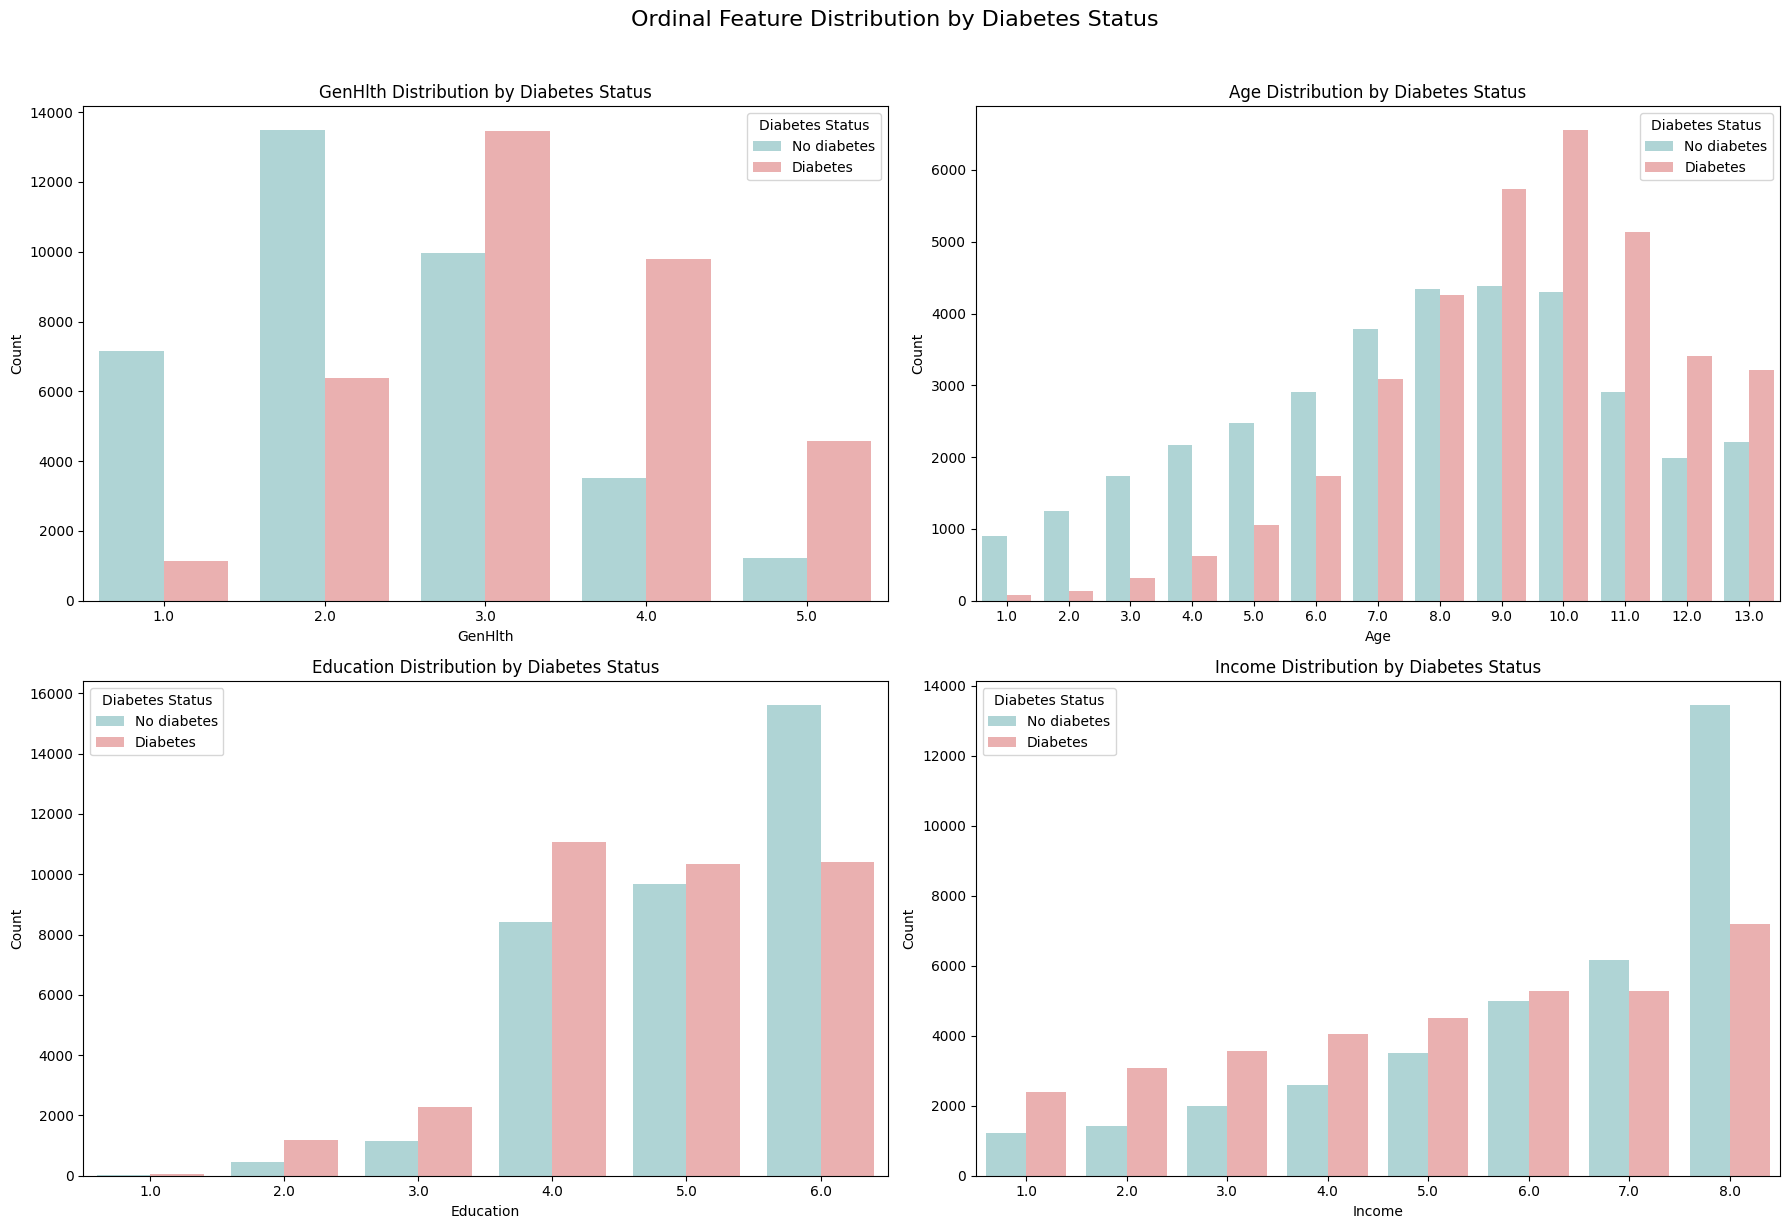

In [ ]:
palette = ['#A8DADC', '#F4A6A6']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(ordinal_features):
    order = sorted(df[feature].dropna().unique())

    sns.countplot(
        data=df,
        x=feature,
        hue='Diabetes_binary',
        order=order,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} Distribution by Diabetes Status', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    # Better legend labels
    handles, _ = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ['No diabetes', 'Diabetes'], title='Diabetes Status')

    # Improve x-axis readability
    axes[i].tick_params(axis='x', rotation=0)

fig.suptitle('Ordinal Feature Distribution by Diabetes Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

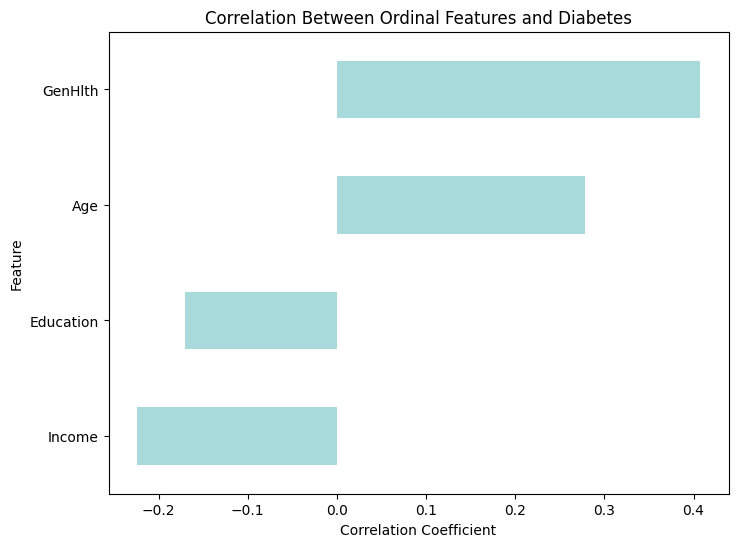

In [ ]:
plt.figure(figsize=(8, 6))

numeric_correlations = (
    df[ordinal_features]
    .corrwith(df['Diabetes_binary'])
)

numeric_correlations.sort_values().plot(
    kind='barh',
    color='#A8DADC'
)

plt.title('Correlation Between Ordinal Features and Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')

plt.show()

### 5.4 Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between variables in the dataset. Examining these relationships can provide additional insight into which features are most strongly associated with diabetes and may contribute more significantly to predictive modeling.

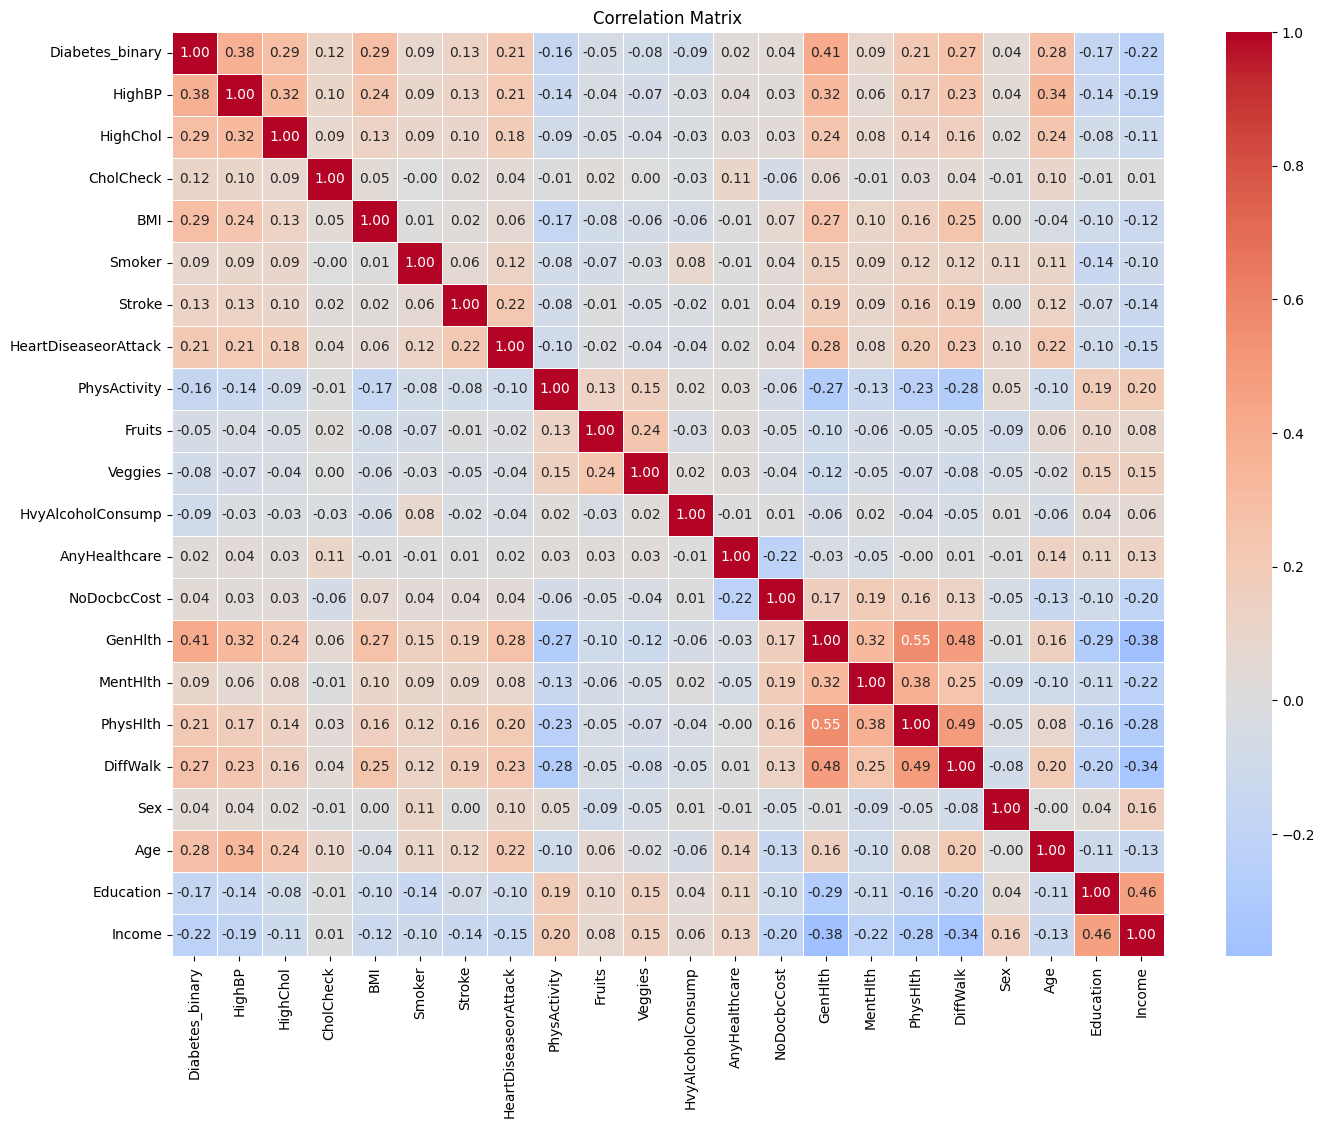

In [ ]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title('Correlation Matrix')
plt.show()

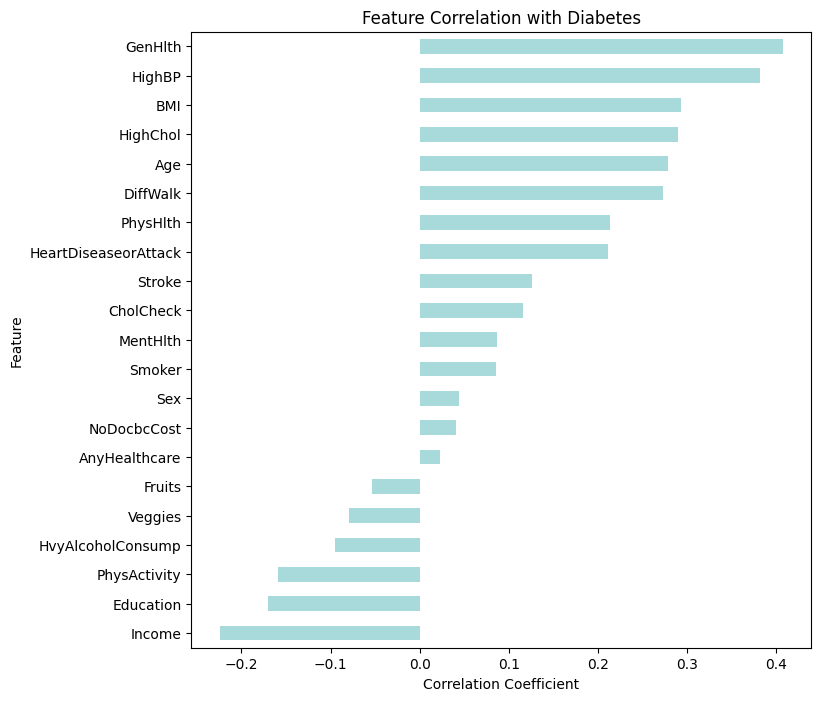

In [ ]:
correlation_target = (
    df.corr()['Diabetes_binary']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

correlation_target.drop('Diabetes_binary').sort_values().plot(
    kind='barh',
    color='#A8DADC'
)

plt.title('Feature Correlation with Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')

plt.show()

### 5.5 Interpreting the Correlation Results

The correlation analysis suggests that several variables show a meaningful association with diabetes, with self-reported general health, high blood pressure, BMI, and age standing out among the strongest relationships. These results are consistent with the patterns observed in the previous visualizations and help identify the variables that may be most informative for prediction.

However, it is important to remember that correlation does not imply causation. For example, the relationship between `HighBP` and `Diabetes_binary` does not mean that high blood pressure directly causes diabetes. Instead, both conditions may be influenced by shared factors such as age, excess body weight, physical inactivity, and broader health status.

The association between diabetes and high blood pressure is also clinically relevant. People with diabetes are more likely to have high blood pressure, and both conditions increase the risk of cardiovascular and kidney complications. This may help explain why high blood pressure appears so frequently among individuals in the diabetes group.

Overall, the correlation analysis provides valuable insight into the variables most strongly associated with diabetes, but further investigation and predictive modeling are still needed before drawing conclusions about causality.

### 5.6 Feature Selection

Before continuing, a feature selection step is performed to remove variables with very weak correlations to the target variable. Including features with little predictive value may introduce unnecessary noise into the model and potentially reduce its ability to identify meaningful patterns.

For this reason, the following variables will be removed from the dataset:

- `Fruits`
- `Veggies`
- `Sex`
- `CholCheck`
- `AnyHealthcare`
- `NoDocbcCost`

These variables showed relatively weak relationships with diabetes during the exploratory and correlation analysis stages. By removing less informative features, the model may achieve better generalization and focus more effectively on the variables that contribute most strongly to prediction performance.

In [ ]:
df = df.drop(columns=[
    'Fruits',
    'Veggies',
    'Sex',
    'CholCheck',
    'AnyHealthcare',
    'NoDocbcCost'
])

# <span style="font-family:serif; font-size:28px;">6. Data Preprocessing</span>

Before training the machine learning models, the dataset must be prepared through a preprocessing pipeline. Although all variables are stored as numeric values, they do not all represent the same type of information. Some features are binary, others represent ordinal categories, and a few correspond to continuous or count-based variables.

For this reason, the preprocessing strategy is adapted to the nature of each feature type. Continuous, count-based, and ordinal variables are standardized using `StandardScaler` so that they share a comparable scale and do not disproportionately influence the models. Binary variables, however, are kept in their original encoded form to preserve their categorical meaning.

Finally, the dataset is divided into training and testing sets to evaluate model performance on unseen data. A `ColumnTransformer` is used to combine the preprocessing steps into a single and consistent workflow, ensuring that the appropriate transformations are applied to each feature group during model training and evaluation.

### 6.1 Define Features and Target

In [ ]:
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

### 6.2 Split the Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6.3 Create Preprocessing Pipeline

In [ ]:
binary_features = [
    'HighBP', 'HighChol', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity',
    'HvyAlcoholConsump', 'DiffWalk'
]

ordinal_features = [
    'GenHlth',
    'Age',
    'Education',
    'Income'
]

numerical_features = [
    'BMI',
    'MentHlth',
    'PhysHlth'
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('bin', StandardScaler(), binary_features),
    ('ord', 'passthrough', ordinal_features)
])

# <span style="font-family:serif; font-size:28px;">7. Machine Learning Model Selection</span>

With the data prepared and the main feature relationships explored, the next step is to train predictive models capable of identifying individuals at risk of diabetes. Since this is a supervised binary classification problem, several machine learning algorithms can be evaluated and compared based on their predictive performance.

Different models capture patterns in different ways. Simpler linear models may provide greater interpretability, while more complex ensemble methods can capture nonlinear relationships and interactions among variables more effectively. Evaluating multiple approaches allows for a better understanding of which models are most suitable for this dataset and prediction task.

### 7.1 Model Comparison

Logistic Regression, K-Nearest Neighbors, Random Forest, and XGBoost are evaluated using the ROC-AUC metric. ROC-AUC is particularly appropriate for this classification task because it measures the ability of a model to distinguish between individuals with and without diabetes across different decision thresholds.

Evaluating multiple algorithms also allows for a comparison between linear, distance-based, and ensemble learning approaches, helping identify which models are most effective at capturing the underlying patterns within the dataset.

In [ ]:
models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('model', model)
  ])

  scores = cross_val_score(
      pipeline,
      X_train,
      y_train,
      cv=cv,
      scoring='roc_auc',
      n_jobs=-1
  )

  print(f'{name}:')
  print(f'Mean ROC-AUC: {scores.mean():.4f}')
  print(f'Std: {scores.std():.4f}')
  print('-' * 40)

Logistic Regression:
Mean ROC-AUC: 0.8227
Std: 0.0023
----------------------------------------
K-Nearest Neighbors:
Mean ROC-AUC: 0.7692
Std: 0.0022
----------------------------------------
Random Forest:
Mean ROC-AUC: 0.8258
Std: 0.0014
----------------------------------------
XGBoost:
Mean ROC-AUC: 0.8273
Std: 0.0017
----------------------------------------


Although K-Nearest Neighbors was included in the initial model comparison, its ROC-AUC score was notably lower than the other candidates. For this reason, it will not be considered in the hyperparameter tuning stage. The analysis will instead focus on the models that achieved stronger baseline performance, allowing for a more efficient and meaningful optimization process.

One possible explanation for the weaker performance of K-Nearest Neighbors is that the dataset contains overlapping patterns between diabetic and non-diabetic individuals rather than clearly separated groups. Since KNN relies on distance calculations to classify observations, it can struggle when class boundaries are diffuse or when many features contribute differently to the prediction task. In contrast, models such as Random Forest and XGBoost are generally better at capturing complex nonlinear relationships and interactions among variables, which may explain their superior performance in this dataset.

### 7.2 Model Optimization and Selection

In this stage, the three best-performing models from the baseline evaluation are further optimized through hyperparameter tuning. The objective is to improve predictive performance while ensuring that the models generalize well to unseen data.

Each model is evaluated on both training and testing data to identify potential underfitting or overfitting issues. Comparing performance across datasets allows for a more reliable assessment of model stability and generalization capability. Finally, the strongest model is selected based on its overall predictive performance and consistency.

In [ ]:
# Logistic Regression

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

logreg_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs'],
    'model__max_iter': [1500]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_params,
    n_iter=4,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Random Forest

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# XGBOOST

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
    ))
])

xgb_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 6],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Fit Searches

logreg_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['BMI',
                                                                                'MentHlth',
                                                                                'PhysHlth']),
                                                                              ('bin',
                                                                               StandardScaler(),
                                                                               ['HighBP',
                                                                                'HighChol',
                                                                                'Smoker',
                                                                                'Stroke',
                                                                                'HeartDiseaseorAttack',
                                                                                'PhysActivity',
                                                                                'HvyAlcoholConsump',
                                                                                'DiffWalk']),
                                                                              ('ord',
                                                                               'passthrough',
                                                                               ['GenHlth',
                                                                                'Age',
                                                                                'Education',
                                                                                'Income'])]))...
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=-1,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 6],
                                        'model__n_estimators': [100, 200],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

In [ ]:
searches = {
    'Logistic Regression': logreg_search,
    'Random Forest': rf_search,
    'XGBoost': xgb_search
}

for name, search in searches.items():

    # Best tuned model
    best_model = search.best_estimator_

    # Predictions
    train_probs = best_model.predict_proba(X_train)[:, 1]
    test_probs = best_model.predict_proba(X_test)[:, 1]

    # ROC-AUC scores
    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)

    print(f'{name}')
    print(f'Best Parameters: {search.best_params_}')
    print(f'Train ROC-AUC: {train_auc:.4f}')
    print(f'Test ROC-AUC: {test_auc:.4f}')
    print('-' * 50)

Logistic Regression
Best Parameters: {'model__solver': 'lbfgs', 'model__max_iter': 1500, 'model__C': 1}
Train ROC-AUC: 0.8228
Test ROC-AUC: 0.8205
--------------------------------------------------
Random Forest
Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10}
Train ROC-AUC: 0.8518
Test ROC-AUC: 0.8255
--------------------------------------------------
XGBoost
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Train ROC-AUC: 0.8321
Test ROC-AUC: 0.8274
--------------------------------------------------


Logistic Regression and XGBoost showed similar performance on both the training and test sets, which suggests that both models generalize well to unseen data. Random Forest, on the other hand, showed a more noticeable drop in ROC-AUC from training to test performance, which may indicate some degree of overfitting.

For this reason, XGBoost will be selected as the final model. Although Logistic Regression achieved a comparable score with a simpler and more interpretable structure, XGBoost offers slightly greater flexibility for capturing nonlinear patterns and interactions among variables. The fact that Logistic Regression performed so well is also informative, as it suggests that the relationship between the predictors and diabetes risk may not be highly complex.

In [ ]:
best_model = Pipeline([-
    ('preprocessor', preprocessor),

    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['BMI', 'MentHlth',
                                                   'PhysHlth']),
                                                 ('bin', StandardScaler(),
                                                  ['HighBP', 'HighChol',
                                                   'Smoker', 'Stroke',
                                                   'HeartDiseaseorAttack',
                                                   'PhysActivity',
                                                   'HvyAlcoholConsump',
                                                   'DiffWalk']),
                                                 ('ord', 'passthrough',
                                                  ['GenHlth', 'Age',
                                                   'Education', 'Income'])])),
                ('model',
                 XGBClassifier(base_score...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

# <span style="font-family:serif; font-size:28px;">8. Model Evaluation</span>

After selecting Logistic Regression as the final model, the next step is to evaluate its predictive performance in greater detail. While ROC-AUC provides an overall measure of the model's ability to distinguish between early and non-early wakers, additional metrics help assess its performance from different perspectives.

The model will be evaluated using a classification report, confusion matrix, ROC curve, and precision-recall curve. Together, these metrics provide a comprehensive view of the model's predictive capability and the trade-offs associated with different classification thresholds.

### 8.1 Initial Prediction Performance Analysis

To gain a more comprehensive understanding of the model’s predictive performance, the evaluation begins with a classification report. This report summarizes several important metrics, including precision, recall, and F1-score. Precision measures how many predicted positive cases were actually correct, recall evaluates how effectively the model identifies actual positive cases, and the F1-score provides a balanced measure between precision and recall.

After reviewing these metrics, the predictions are visualized using a confusion matrix. This allows for a clearer interpretation of the model’s classification behavior by showing the number of correct and incorrect predictions for each class, including false positives and false negatives.

In [ ]:
y_pred = best_model.predict(X_test)

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(2))

,precision,recall,f1-score,support
0.0,0.77,0.71,0.74,7070.00
1.0,0.73,0.79,0.76,7069.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.75,0.75,0.75,14139.00
weighted avg,0.75,0.75,0.75,14139.00


<Figure size 600x500 with 0 Axes>

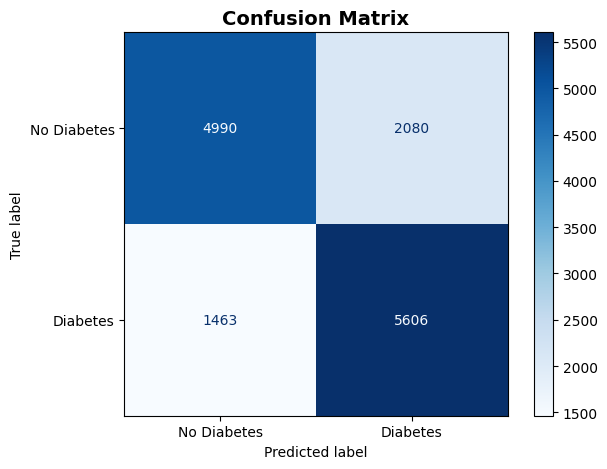

In [ ]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues',
    values_format='d'
)

plt.title(
    'Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 8.2 ROC Curve Analysis

The ROC (Receiver Operating Characteristic) curve evaluates the model's ability to distinguish between diabetic and non-diabetic individuals across different classification thresholds.

The curve plots the True Positive Rate (Recall) against the False Positive Rate, while the Area Under the Curve (ROC-AUC) summarizes the model's overall discriminative ability. An ROC-AUC of 0.5 indicates performance equivalent to random guessing, whereas a value of 1.0 represents perfect classification.

The model achieved an ROC-AUC of approximately 0.83, indicating a strong ability to separate diabetic from non-diabetic individuals. This result is consistent with the performance observed during cross-validation and suggests that the model generalizes well to unseen data.

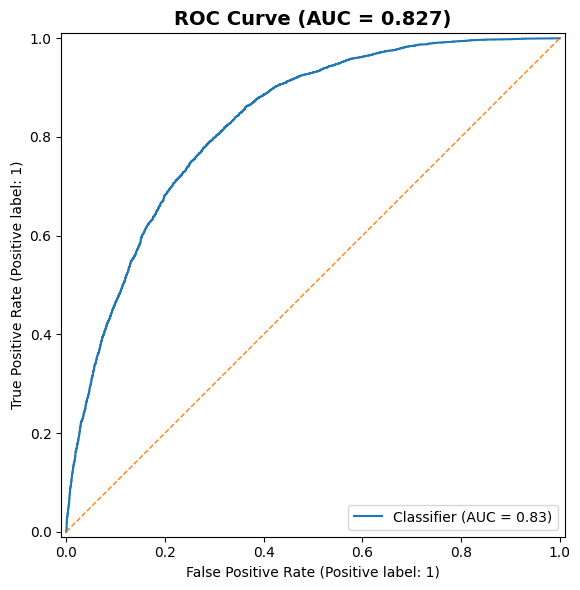

In [ ]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

plt.title(
    f'ROC Curve (AUC = {roc_auc:.3f})',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 8.3 Precision-Recall Curve Analysis

The Precision-Recall curve provides a detailed view of the trade-off between precision and recall across different classification thresholds. While precision measures the proportion of predicted diabetic cases that are actually diabetic, recall measures the proportion of diabetic individuals that are successfully identified by the model.

The model achieved an Average Precision (AP) score of **0.82**, indicating strong performance in maintaining a balance between identifying diabetic individuals and limiting false positive predictions. This result is consistent with the ROC-AUC score obtained previously and suggests that the model is capable of reliably distinguishing between diabetic and non-diabetic individuals across a range of threshold values.

Overall, the Precision-Recall curve reinforces the conclusion that the selected XGBoost model provides robust predictive performance and generalizes well to unseen data, making it a suitable candidate for diabetes risk prediction.

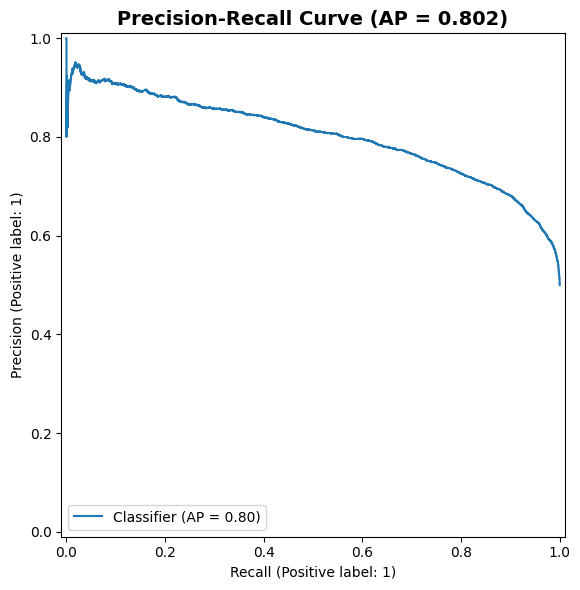

In [ ]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Average Precision Score
avg_precision = average_precision_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    ax=plt.gca()
)

plt.title(
    f'Precision-Recall Curve (AP = {avg_precision:.3f})',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 8.4 Threshold Adjustment

By default, classification models use a probability threshold of 0.50 to determine whether an observation belongs to the positive class. However, this threshold may not always be optimal depending on the objective of the analysis.

In healthcare applications, the cost of missing a diabetic individual (false negative) may be higher than incorrectly flagging a healthy individual as diabetic (false positive). For this reason, the classification threshold can be adjusted to modify the balance between precision and recall. Lowering the threshold generally increases recall by identifying more diabetic individuals, while raising the threshold typically increases precision by reducing false positive predictions.

The following analysis explores how different threshold values affect the model's classification performance.

In [ ]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

for threshold in [0.40, 0.45, 0.50, 0.55, 0.60]:

    y_pred_custom = (
        y_pred_proba >= threshold
    ).astype(int)

    print(f'\nThreshold: {threshold}')
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.83      0.62      0.71      7070
         1.0       0.70      0.87      0.77      7069

    accuracy                           0.75     14139
   macro avg       0.76      0.75      0.74     14139
weighted avg       0.76      0.75      0.74     14139


Threshold: 0.45
              precision    recall  f1-score   support

         0.0       0.80      0.66      0.72      7070
         1.0       0.71      0.83      0.77      7069

    accuracy                           0.75     14139
   macro avg       0.76      0.75      0.75     14139
weighted avg       0.76      0.75      0.75     14139


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      7070
         1.0       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75  

The threshold analysis highlights the trade-off between identifying diabetic individuals and minimizing false positive predictions. Lower thresholds increase recall by identifying a greater proportion of diabetic patients, while higher thresholds improve precision at the cost of missing more positive cases.

For this project, a threshold of 0.40 may be preferred because the primary objective is to identify as many diabetic individuals as possible. At this threshold, the model correctly identifies 87% of diabetic patients, reducing the number of missed cases compared with the default threshold of 0.50.

Although this approach increases the number of false positive predictions, the model can be viewed as a screening tool rather than a diagnostic system. In such scenarios, incorrectly flagging a healthy individual for additional testing is often considered less costly than failing to identify a person who may have diabetes. Therefore, prioritizing recall provides a reasonable trade-off for the objectives of this analysis.


In [ ]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

threshold = 0.40

y_pred_final = (
    y_pred_proba >= threshold
).astype(int)

<Figure size 600x500 with 0 Axes>

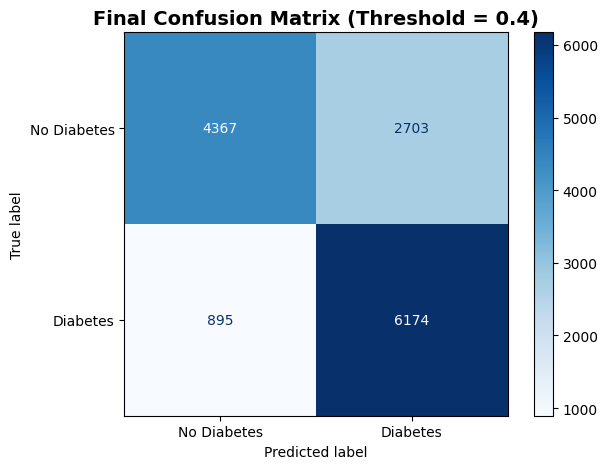

In [ ]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=['No Diabetes', 'Diabetes'],
    cmap='Blues'
)

plt.title(
    f'Final Confusion Matrix (Threshold = {threshold})',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 8.5 Feature Importance

Understanding which variables contribute most to the model's predictions is an important part of model interpretation. Although XGBoost is more complex than linear models, it provides feature importance scores that indicate how much each variable contributes to the decision-making process.

The following visualization highlights the most influential features used by the model when predicting diabetes. These results can be compared with the findings from the exploratory data analysis and correlation analysis to determine whether the model is relying on the same patterns identified earlier in the project.

In [2]:
# Extract feature names from the preprocessor
feature_names = (
    best_model.named_steps['preprocessor']
    .get_feature_names_out()
)

# Extract XGBoost feature importances
importances = (
    best_model.named_steps['model']
    .feature_importances_
)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Remove ColumnTransformer prefixes
feature_importance['Feature'] = (
    feature_importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('ord__', '', regex=False)
    .str.replace('bin__', '', regex=False)
)

# Map technical variable names to business-friendly labels
feature_labels = {
    'HighBP': 'High Blood Pressure',
    'HighChol': 'High Cholesterol',
    'BMI': 'Body Mass Index (BMI)',
    'Smoker': 'Smoking History',
    'Stroke': 'Previous Stroke',
    'HeartDiseaseorAttack': 'Heart Disease / Heart Attack',
    'PhysActivity': 'Physical Activity',
    'HvyAlcoholConsump': 'Heavy Alcohol Consumption',
    'GenHlth': 'Self-Reported General Health',
    'MentHlth': 'Poor Mental Health Days',
    'PhysHlth': 'Poor Physical Health Days',
    'DiffWalk': 'Difficulty Walking',
    'Age': 'Age Group',
    'Education': 'Education Level',
    'Income': 'Income Level'
}

feature_importance['Feature'] = (
    feature_importance['Feature']
    .replace(feature_labels)
)

# Keep top 15 features
feature_importance = (
    feature_importance
    .sort_values(by='Importance', ascending=False)
    .head(15)
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='mako'
)

plt.title(
    'Top 15 Most Important Features',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

NameError: name 'best_model' is not defined

# <span style="font-family:serif; font-size:28px;">9. Conclusions</span>

This project explored the main health, lifestyle, and demographic factors associated with diabetes risk using the BRFSS 2015 dataset. Through exploratory analysis, correlation analysis, model comparison, and final model evaluation, it became clear that diabetes is not explained by a single variable, but rather by a combination of interrelated health indicators and personal characteristics.

Among the variables analyzed, **high blood pressure**, **self-reported general health**, **high cholesterol**, **age**, and **BMI** emerged as the strongest predictors in the final model. These findings are consistent with both the exploratory analysis and the feature importance results, reinforcing the idea that diabetes risk is closely linked to overall health status, body composition, and age-related factors.

The modeling stage showed that XGBoost delivered the strongest overall performance, with solid generalization on unseen data. At the same time, the fact that Logistic Regression also performed competitively suggests that the relationships in this dataset are meaningful and informative, but not excessively complex. This is an encouraging result, as it indicates that the selected variables capture a strong and relatively interpretable signal.

The threshold analysis also highlighted the trade-off between precision and recall. By lowering the classification threshold, the model became more sensitive to diabetic cases, which is often desirable in a healthcare screening context where missing a true positive can have serious consequences. This reinforces the importance of choosing evaluation criteria based not only on statistical performance, but also on the practical cost of different types of errors.

Overall, this notebook demonstrates how data preprocessing, exploratory analysis, model selection, and threshold tuning can be combined to build a thoughtful predictive workflow. While the model is not intended to serve as a medical diagnostic tool, it shows that machine learning can be used to identify patterns associated with diabetes risk and support early screening efforts. In future work, the analysis could be extended with additional feature engineering, calibration analysis, or external validation on a different dataset to further strengthen the model’s reliability.